<div style='background:#1a237e;padding:28px 32px;border-radius:12px'>
  <h1 style='color:white;margin:0;font-size:24px'>CLF02 - Crédit Scoring</h1>
  <h2 style='color:#90caf9;margin:10px 0 4px;font-size:17px'>Notebook 02 · Modélisation & Sélection du Modèle</h2>
  <p style='color:#bbdefb;margin:0;font-size:13px'>Prêt à dépenser — Home Credit Default Risk</p>
</div>

---

## Objectif

Construire un modèle de scoring crédit qui **prédit la probabilité de défaut de paiement** d'un client.
On compare plusieurs algorithmes et on sélectionne le meilleur selon deux critères :
- **AUC-ROC** : capacité discriminante du modèle
- **Coût métier** : coût financier minimisé (un faux négatif coûte 05× plus qu'un faux positif)

## Plan

| # | Section |
|---|--------|
| 0 | Installations & Imports |
| 1 | Préparation des données |
| 2 | Baseline Dummy |
| 3 | Régression Logistique |
| 4 | K-Nearest Neighbors (KNN) |
| 5 | Arbre de Décision |
| 6 | Random Forest |
| 7 | XGBoost |
| 8 | CatBoost |
| 9 | **LightGBM** (modèle retenu) |
| 10 | Synthèse comparative |
| 11 | Runs MLflow |
| 12 | Stacking Ensemble |
| 13 | Interprétabilité SHAP |

> **Données** : base fusionnée `train_final.csv` produite par le notebook 01 (fusion des 8 tables Home Credit).

---
## 0 · Installations & Imports

Installation des librairies non présentes par défaut dans l'environnement :
`mlflow` pour le tracking des expériences et `catboost` pour l'algorithme CatBoost.

In [1]:
pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.

In [2]:
pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.0 MB/s eta 0:00:00


#### Imports principaux

In [6]:
# Manipulation de données et système
import pandas as pd
import numpy as np
import os
import re
import gc
import joblib
import gdown
from google.colab import drive

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Tracking et modèles de boosting
import mlflow
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Scikit-Learn : Prétraitement et Pipelines
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Scikit-Learn : Validation et Sélection de modèles
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.utils import resample

# Scikit-Learn : Modèles
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

# Scikit-Learn : Métriques
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, f1_score, classification_report,
    accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay
)

# Gestion du déséquilibre des classes (Imbalanced-learn)
from imblearn.under_sampling import RandomUnderSampler


# Configuration de la reproductibilité
SEED = 123
np.random.seed(SEED)

# Montage Google Drive et configuration MLflow
drive.mount('/content/drive')
CHEMIN_DRIVE_TRACKING = '/content/drive/MyDrive/Projet_ML2/MLFlow_Tracking'
mlflow.set_tracking_uri(f'file://{CHEMIN_DRIVE_TRACKING}')
mlflow.set_experiment('Pret_A_Depenser_Scoring')



Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:///content/drive/MyDrive/Projet_ML2/MLFlow_Tracking/933425481062839022', creation_time=1776816395529, experiment_id='933425481062839022', last_update_time=1776816395529, lifecycle_stage='active', name='Pret_A_Depenser_Scoring', tags={}, trace_location=None, workspace='default'>

---
## 1 · Préparation des Données

### 1.1 Chargement

On charge la base fusionnée `train_final.csv` qui contient les features agrégées
de toutes les tables secondaires (bureau, previous_application, POS_CASH, etc.).

In [14]:
# Importation des données finales mergées à partir d'un ID google drive
FILE_ID = "1oUmvP8_bHkBNaWcBhpeiFZpNNWv4GVbw"
output = "train_final.csv"
gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', output, quiet=False)

# Chargement du fichier téléchargé localement
df = pd.read_csv(output)
print(f"Base chargée : {df.shape[0]} lignes et {df.shape[1]} variables.")

# Séparation Features / Target
X = df.drop(columns=['SK_ID_CURR', 'TARGET'])
y = df['TARGET']

# Nettoyage des noms de colonnes (suppression des caractères spéciaux liés à la fusion)
import re
X = X.rename(columns = lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))

Downloading...
From (original): https://drive.google.com/uc?id=1oUmvP8_bHkBNaWcBhpeiFZpNNWv4GVbw
From (redirected): https://drive.google.com/uc?id=1oUmvP8_bHkBNaWcBhpeiFZpNNWv4GVbw&confirm=t&uuid=97b1e0f8-dc40-4aa0-b55b-be28a803d8c3
To: /content/train_final.csv
100%|██████████| 687M/687M [00:06<00:00, 111MB/s]


Base chargée : 307511 lignes et 444 variables.


### 1.2 Split Train / Test

On sépare les données en **80% train** et **20% test** avec stratification sur `TARGET`
pour conserver le ratio de défauts (~8%) dans les deux ensembles.

In [16]:
# Séparation 80% Train / 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y # Garde la même proportion de pour la variable cible
)

print(f"Taille du Train set : {X_train.shape}")
print(f"Taille du Test set : {X_test.shape}")

Taille du Train set : (246008, 442)
Taille du Test set : (61503, 442)


### 1.3 Encodage des variables catégorielles

Conversion des colonnes `object` en type `category` — format natif accepté par LightGBM et CatBoost
sans nécessiter de One-Hot Encoding.

In [17]:
# Conversion des colonnes de type 'object' en 'category'
for col in X_train.select_dtypes(include='object').columns:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

print("Conversion des colonnes catégorielles en type 'category' effectuée.")

Conversion des colonnes catégorielles en type 'category' effectuée.


### 1.4 Fonction Coût Métier

La fonction coût traduit l'impact financier des erreurs du modèle :

| Type d'erreur | Situation réelle | Pénalité |
|---------------|-----------------|----------|
| **Faux Négatif (FN)** | Prêter à un client qui va faire défaut | **Coût × 05** |
| **Faux Positif (FP)** | Refuser un bon client | **Coût × 1** |

Un faux négatif est **05 fois plus coûteux** : la banque perd l'argent prêté.
Le modèle doit donc être plus prudent sur les faux négatifs .

In [18]:
def custom_business_cost(y_true, y_pred_proba, threshold=0.5):
    """
    Calcule le coût financier théorique.
    FN (Défaut non détecté) : Coût 5
    FP (Refus injustifié) : Coût 1
    """
    y_pred = (y_pred_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return (5 * fn) + (1 * fp)

# Grille de seuils pour l'optimisation métier
thresholds = np.linspace(0.01, 0.99, 100)

### 1.5 Fonction de Visualisation

Fonction `plot_model_performance` qui génère 3 graphiques pour chaque modèle :
courbe ROC,coût métier en fonction du seuil, et matrice de confusion.

In [19]:
from sklearn.metrics import roc_curve

def plot_model_performance(y_true, y_proba, thresholds, model_name):
    """
    Affiche la matrice de confusion (au seuil optimal), la courbe ROC
    et la courbe d'optimisation du coût métier.
    """
    # Calcul des coûts pour chaque seuil
    costs = [custom_business_cost(y_true, y_proba, threshold=t) for t in thresholds]
    min_cost = min(costs)
    opt_threshold = thresholds[costs.index(min_cost)]

    # Prédiction avec le seuil optimal
    y_pred = (y_proba >= opt_threshold).astype(int)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f'Performance - {model_name}', fontsize=16)

    # 1. Matrice de Confusion
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'Confusion Matrix (Threshold: {opt_threshold:.2f})')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    # 2. Courbe ROC
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc_score = roc_auc_score(y_true, y_proba)
    axes[1].plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {auc_score:.4f})')
    axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
    axes[1].set_title('ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc="lower right")

    # 3. Optimisation du Coût Métier
    axes[2].plot(thresholds, costs, color='green')
    axes[2].axvline(opt_threshold, color='red', linestyle='--', label=f'Opt. Threshold: {opt_threshold:.2f}')
    axes[2].set_title('Business Cost Optimization')
    axes[2].set_xlabel('Threshold')
    axes[2].set_ylabel('Total Cost')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    return opt_threshold, min_cost

### 1.6 Préprocesseur sklearn

Pipeline de prétraitement pour les modèles nécessitant des données numériques normalisées
(Régression Logistique, KNN, Decision Tree) :
- **Variables numériques** : imputation par la médiane + standardisation (StandardScaler)
- **Variables catégorielles** : imputation + One-Hot Encoding

LightGBM, XGBoost et CatBoost n'ont **pas besoin** de ce préprocesseur.

# 1. Préparation des Données et Pipeline
Sélection des variables significatives et définition du preprocessor pour les modèles de base.

In [20]:
# Liste des 20 variables significatives les plus significative identifiées lors de l'EDA
selected_features = [
    'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'INST_DPD_LATE_MEAN', 'AMT_CREDIT', 'INST_AMT_PAYMENT_SUM', 'AMT_ANNUITY',
    'DAYS_EMPLOYED', 'POS_CNT_INSTALMENT_FUTURE_MEAN', 'AMT_GOODS_PRICE',
    'INST_DBD_MEAN', 'BURO_DAYS_CREDIT_MAX', 'PREV_CNT_PAYMENT_MEAN',
    'BURO_DAYS_CREDIT_ENDDATE_MAX', 'OCCUPATION_TYPE', 'DAYS_ID_PUBLISH',
    'CC_CNT_DRAWINGS_ATM_CURRENT_MEAN', 'OWN_CAR_AGE', 'CODE_GENDER'
]

# Filtrage des données
existing_features = [c for c in selected_features if c in X_train.columns]
X_train_sub = X_train[existing_features]
X_test_sub = X_test[existing_features]

# Identification des types de colonnes pour le preprocessor
numeric_features = X_train_sub.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train_sub.select_dtypes(include=['object', 'category']).columns.tolist()

# --- Definition ddu processing ---

# Numérique
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Catégoriel (OneHot encoding)
onehot_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='undefined')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Pipeline de preprocessing global
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', onehot_transformer, categorical_features)
])



---
## 2 · Baseline Dummy — Plancher de Référence

Le `DummyClassifier` prédit aléatoirement ou toujours la classe majoritaire.
Il sert à établir la **base** : tout modèle utile doit faire mieux.

In [ ]:
with mlflow.start_run(run_name='Dummy_Classifier_Baseline'):
    dummy_pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DummyClassifier(strategy='stratified', random_state=SEED))
    ])
    dummy_pipe.fit(X_train_sub, y_train)

    y_proba_dummy = dummy_pipe.predict_proba(X_test_sub)[:, 1]
    auc_dummy = roc_auc_score(y_test, y_proba_dummy)

    dummy_costs = [custom_business_cost(y_test, y_proba_dummy, threshold=t) for t in thresholds]
    min_cost_dummy = min(dummy_costs)

    print(f'Dummy AUC: {auc_dummy:.4f}')
    print(f'Dummy Business Cost: {min_cost_dummy}')

    mlflow.log_metric('AUC_ROC', auc_dummy)
    mlflow.log_metric('Business_Cost_Min', min_cost_dummy)

Dummy AUC: 0.4988
Dummy Business Cost: 27426


**Interprétation — Baseline Dummy** :

L'AUC-ROC du Dummy est de **0.50**, ce qui correspond au niveau aléatoire.
C'est la base de référence.
Tout modèle entraîné sur les données réelles doit donc obtenir un AUC **strictement supérieur à 0.50** pour être utile.

Le coût métier du Dummy est élevé car il accepte ou refuse sans discernement -
il génère beaucoup de faux négatifs (défaillants acceptés).

Visualisation Dummy Classifier :


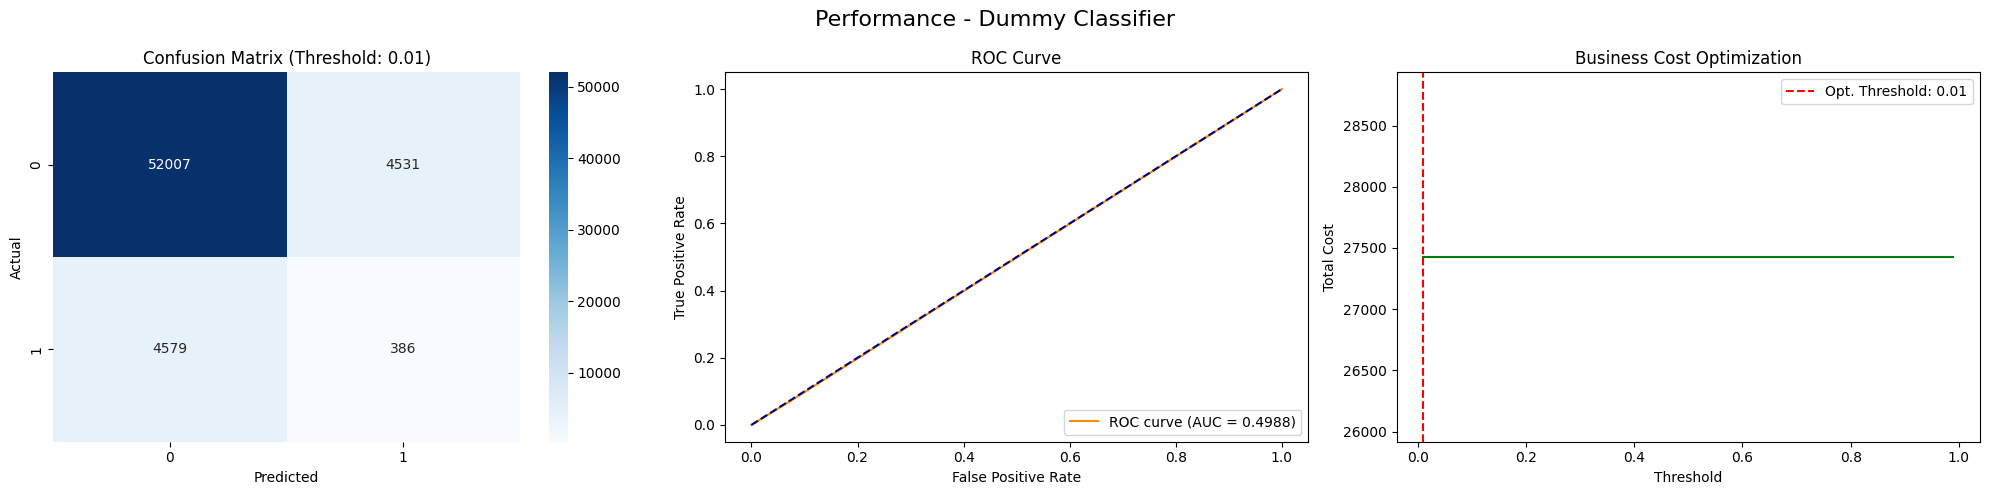

In [ ]:
print("Visualisation Dummy Classifier :")
_, _ = plot_model_performance(y_test, y_proba_dummy, thresholds, 'Dummy Classifier')

---
## 3 · Régression Logistique

Premier modèle pour comparer avec le baseline, entrainé sur les 20 variables les plus significatives identifiées au départ.

In [ ]:
with mlflow.start_run(run_name='Logistic_Regression_Baseline'):
    log_reg_pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED))
    ])

    log_reg_pipe.fit(X_train_sub, y_train)
    y_proba_log = log_reg_pipe.predict_proba(X_test_sub)[:, 1]
    auc_log = roc_auc_score(y_test, y_proba_log)

    log_costs = [custom_business_cost(y_test, y_proba_log, threshold=t) for t in thresholds]
    min_cost_log = min(log_costs)
    opt_threshold_log = thresholds[log_costs.index(min_cost_log)]

    print(f'--- Résultats Régression Logistique ---')
    print(f'AUC-ROC : {auc_log:.4f}')
    print(f'Coût Métier Minimum : {min_cost_log}')

    mlflow.log_metric('AUC_ROC', auc_log)
    mlflow.log_metric('Business_Cost_Min', min_cost_log)
    mlflow.log_metric('Optimal_Threshold', opt_threshold_log)

--- Résultats Régression Logistique ---
AUC-ROC : 0.7427
Coût Métier Minimum : 21763


**Interprétation — Régression Logistique** :

- **AUC-ROC : 0.7427** — nette amélioration par rapport au Dummy (0.50).
Le modèle discrimine correctement, avec un modèle linéaire.
- **Coût métier : 21 763**
La régression logistique peut être limitée par sa nature linéaire : on va tester dans la suite les modèles non linéaire.

Utilisation de `class_weight='balanced'` pour compenser le déséquilibre 92%/8%.

Visualisation Logistic Regression :


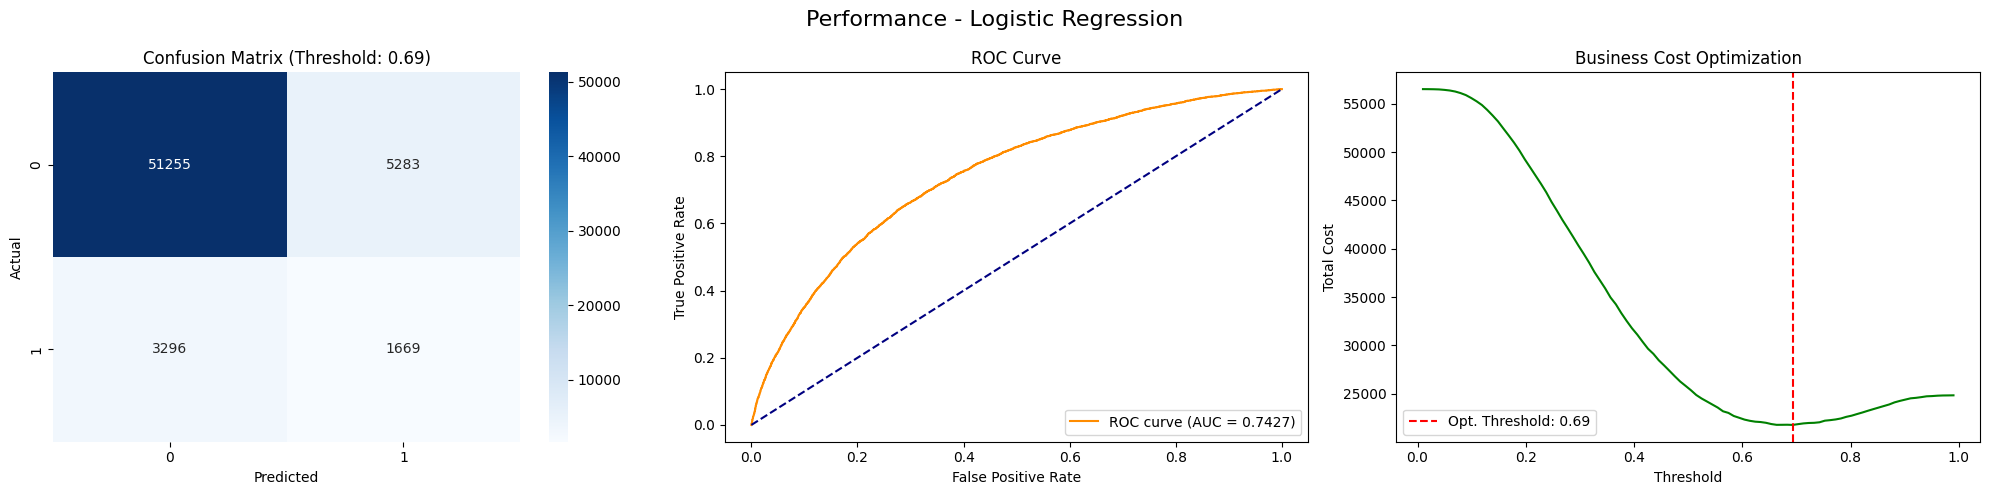

In [ ]:
print("Visualisation Logistic Regression :")
_, _ = plot_model_performance(y_test, y_proba_log, thresholds, 'Logistic Regression')

---
## 4 · K-Nearest Neighbors (KNN)

Le KNN classe un client selon ses **k voisins les plus proches** dans l'espace des features.
Optimisation des hyperparamètres via `RandomizedSearchCV` sur le sous-ensemble de 20 variables.
Entraîné sur un sous-ensemble (sous-échantillonnage avec stratify pour garder les même proportions au niveau de la variable cible) pour limiter le temps d'apprentissage qui explose sinon.

In [ ]:
print("Optimisation du KNN sur un échantillon réduit pour gagner du temps...")

# On entraine le KNN sur un échnatillon réduit du train pour résuire le temps d'entrainement qui exploserait sinon.
X_train_knn, y_train_knn = resample(
    X_train_sub, y_train,
    n_samples=50000,
    replace=False,
    stratify=y_train,
    random_state=SEED
)

# Paramètres à tester
knn_params = {
    'classifier__n_neighbors': [20, 50, 100],
    'classifier__weights': ['uniform', 'distance']
}

# Pipeline KNN
knn_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_jobs=-1))
])

# Recherche d'hyperparamètres
knn_search = RandomizedSearchCV(
    knn_pipe,
    knn_params,
    n_iter=4,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    scoring='roc_auc',
    verbose=1,
    random_state=SEED
)

with mlflow.start_run(run_name="KNN_Optimization_Subsampled"):
    print("Démarrage de la recherche (échantillon de 10k)...")
    knn_search.fit(X_train_knn, y_train_knn)

    best_knn = knn_search.best_estimator_
    y_proba_knn = best_knn.predict_proba(X_test_sub)[:, 1]
    auc_knn = roc_auc_score(y_test, y_proba_knn)

    # Optimisation du seuil
    knn_costs = [custom_business_cost(y_test, y_proba_knn, threshold=t) for t in thresholds]
    min_cost_knn = min(knn_costs)
    opt_threshold_knn = thresholds[knn_costs.index(min_cost_knn)]

    print(f"--- Résultats KNN (Échantillonné) ---")
    print(f"Meilleurs paramètres : {knn_search.best_params_}")
    print(f"AUC-ROC : {auc_knn:.4f}")
    print(f"Seuil Optimal : {opt_threshold_knn:.3f}")
    print(f"Coût Métier Minimum : {min_cost_knn}")

    mlflow.log_params(knn_search.best_params_)
    mlflow.log_metric("AUC_ROC", auc_knn)
    mlflow.log_metric("Business_Cost_Min", min_cost_knn)
    mlflow.log_metric("Optimal_Threshold", opt_threshold_knn)


Optimisation du KNN sur un échantillon réduit pour gagner du temps...
Démarrage de la recherche (échantillon de 10k)...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
--- Résultats KNN (Échantillonné) ---
Meilleurs paramètres : {'classifier__weights': 'uniform', 'classifier__n_neighbors': 100}
AUC-ROC : 0.7154
Seuil Optimal : 0.158
Coût Métier Minimum : 22282


**Interprétation — KNN** :

Le KNN est un algorithme basé sur la similarité locale. Sur ce dataset :
- Il est **coûteux computationnellement** (ce qui a du nous pousser à l'entraîner sur un échantillion)
- Il souffre de la **malédiction de la dimensionnalité** : avec autant de variables,
la notion de 'voisin proche' perd de son sens


Visualisation KNN :


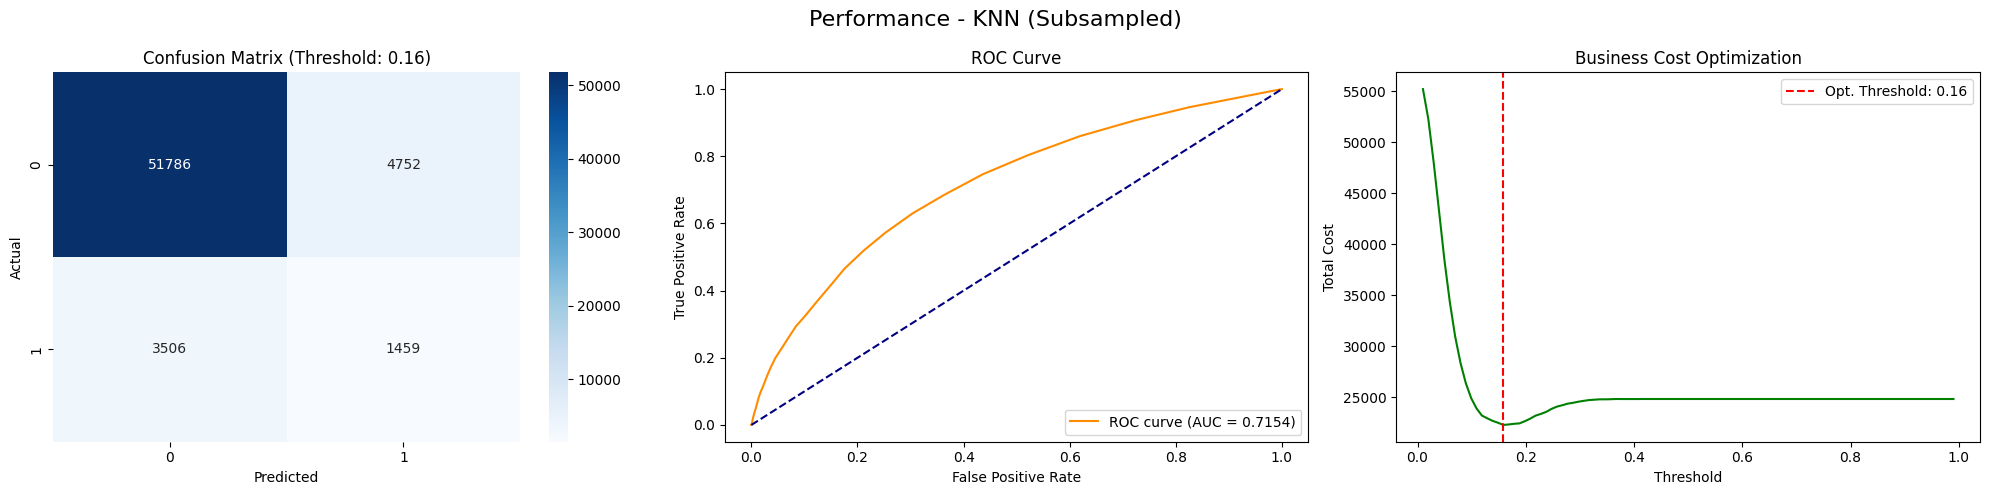

In [ ]:
print("Visualisation KNN :")
_, _ = plot_model_performance(y_test, y_proba_knn, thresholds, 'KNN (Subsampled)')

---
## 5 · Simple Decision Tree (Baseline)

Avant de passer aux ensembles, nous testons un arbre de décision pour évaluer évaluer les performances avant d'utiliser des méthodes ensemblistes
(Random Forest, XGBoost, LightGBM) qui combinent plusieurs d'arbres.

In [ ]:
with mlflow.start_run(run_name="DecisionTree_Baseline"):
    dt_pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=SEED))
    ])

    dt_pipe.fit(X_train_sub, y_train)

    y_proba_dt = dt_pipe.predict_proba(X_test_sub)[:, 1]
    auc_dt = roc_auc_score(y_test, y_proba_dt)

    # Optimisation du seuil
    dt_costs = [custom_business_cost(y_test, y_proba_dt, threshold=t) for t in thresholds]
    min_cost_dt = min(dt_costs)
    opt_threshold_dt = thresholds[dt_costs.index(min_cost_dt)]

    print(f"--- Résultats Simple Decision Tree ---")
    print(f"AUC-ROC : {auc_dt:.4f}")
    print(f"Seuil Optimal : {opt_threshold_dt:.3f}")
    print(f"Coût Métier Minimum : {min_cost_dt}")

    mlflow.log_metric("AUC_ROC", auc_dt)
    mlflow.log_metric("Business_Cost_Min", min_cost_dt)
    mlflow.log_metric("Optimal_Threshold", opt_threshold_dt)


--- Résultats Simple Decision Tree ---
AUC-ROC : 0.7012
Seuil Optimal : 0.752
Coût Métier Minimum : 22473


**Interprétation — Arbre de Décision** :

L'arbre de décision donne des performances plus faibles que les modèles de KNN et de Regression logistique.

Nous allons donc nous pencher à présent sur les modèles ensemblistes.
Random Forest (bagging d'arbres) et Gradient Boosting (LightGBM, XGBoost, CatBoost).

Visualisation Decision Tree :


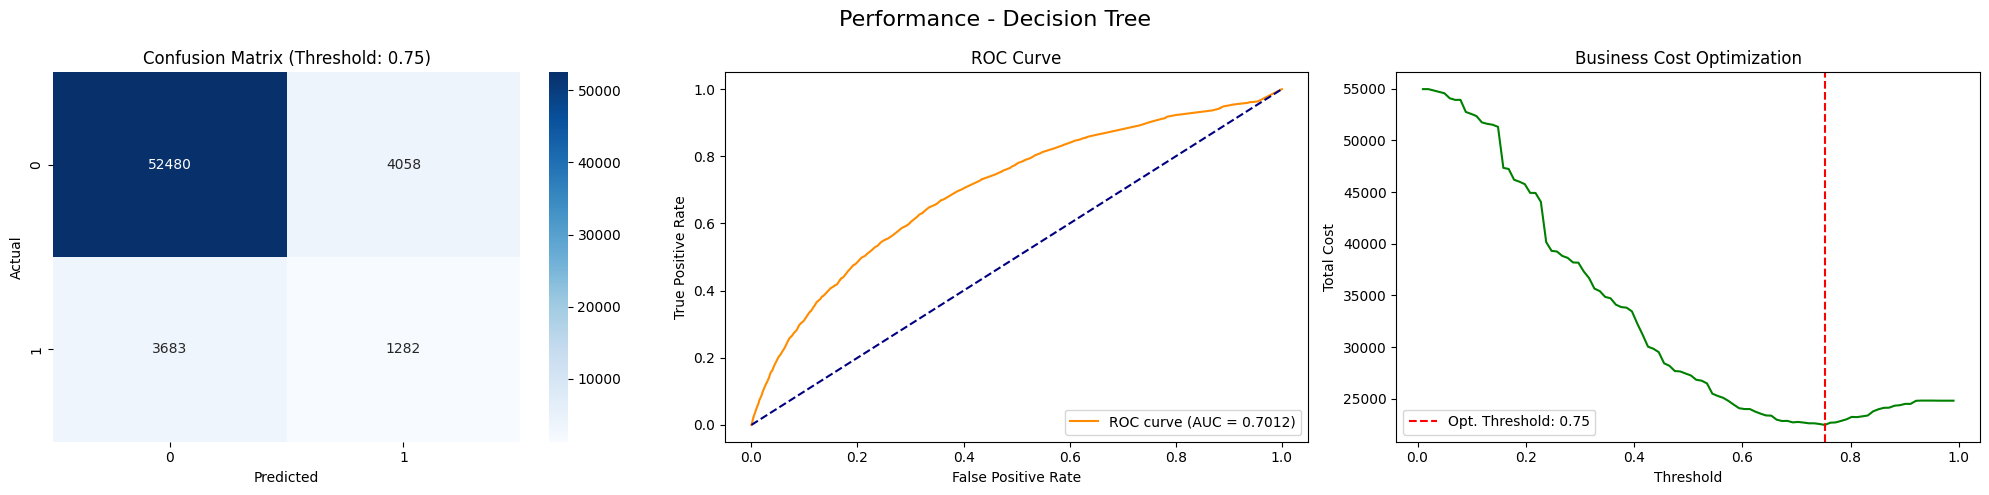

In [ ]:
print("Visualisation Decision Tree :")
_, _ = plot_model_performance(y_test, y_proba_dt, thresholds, 'Decision Tree')

---
## 6 · Random Forest (Sur l'enseble des 400 variables)

Comme suggéré, nous entraînons maintenant un Random Forest sur l'ensemble des données (variables).

In [ ]:
with mlflow.start_run(run_name="RandomForest_Full_Optimized"):
    # 1. Nettoyage des données
    X_train_rf_full = X_train.select_dtypes(exclude=['category', 'object']).replace([np.inf, -np.inf], np.nan).fillna(0)
    X_test_rf_full = X_test.select_dtypes(exclude=['category', 'object']).replace([np.inf, -np.inf], np.nan).fillna(0)

    # 2. Sous-échantillonnage pour l'optimisation comme pour KNN, afin d'éviter le temps d'entainement qui explose.
    X_train_samp, y_train_samp = resample(
        X_train_rf_full, y_train,
        n_samples=50000,
        stratify=y_train,
        random_state=SEED
    )

    # 3. Grille de recherche
    rf_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 15, 20, None],
        'min_samples_leaf': [50, 100]
    }

    rf_base = RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1)

    print(f"Recherche des meilleurs paramètres RF sur échantillon")
    rf_search = RandomizedSearchCV(
        rf_base, rf_grid, n_iter=5, cv=3, scoring='roc_auc', verbose=1, random_state=SEED
    )
    rf_search.fit(X_train_samp, y_train_samp)
    best_rf = rf_search.best_estimator_

    # 4. Entraînement final sur tout le train set
    print("Entraînement final du meilleur modèle sur le dataset complet...")
    best_rf.fit(X_train_rf_full, y_train)

    # 5. Évaluation et Seuil
    y_proba_rf = best_rf.predict_proba(X_test_rf_full)[:, 1]
    auc_rf = roc_auc_score(y_test, y_proba_rf)

    rf_costs = [custom_business_cost(y_test, y_proba_rf, threshold=t) for t in thresholds]
    min_cost_rf = min(rf_costs)

    print(f"RF AUC: {auc_rf:.4f}")
    print(f"RF Business Cost: {min_cost_rf}")

    mlflow.log_params(rf_search.best_params_)
    mlflow.log_metric("AUC_ROC", auc_rf)
    mlflow.log_metric("Business_Cost_Min", min_cost_rf)

Recherche des meilleurs paramètres RF sur échantillon
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Entraînement final du meilleur modèle sur le dataset complet...
RF AUC: 0.7563
RF Business Cost: 21181


**Interprétation — Random Forest** :

Le Random Forest améliore significativement l'arbre simple grâce au **bagging** :
en combinant les prédictions de plusieurs centaines d'arbres indépendants,
il réduit la variance et améliore la généralisation.

Cependant, le Random Forest présente des limites par rapport au Gradient Boosting :
- Il entraîne tous les arbres **en parallèle** (indépendants) → moins efficace pour réduire le biais
- LightGBM entraîne les arbres **séquentiellement** en corrigeant les erreurs du précédent → meilleur AUC


Visualisation Random Forest :


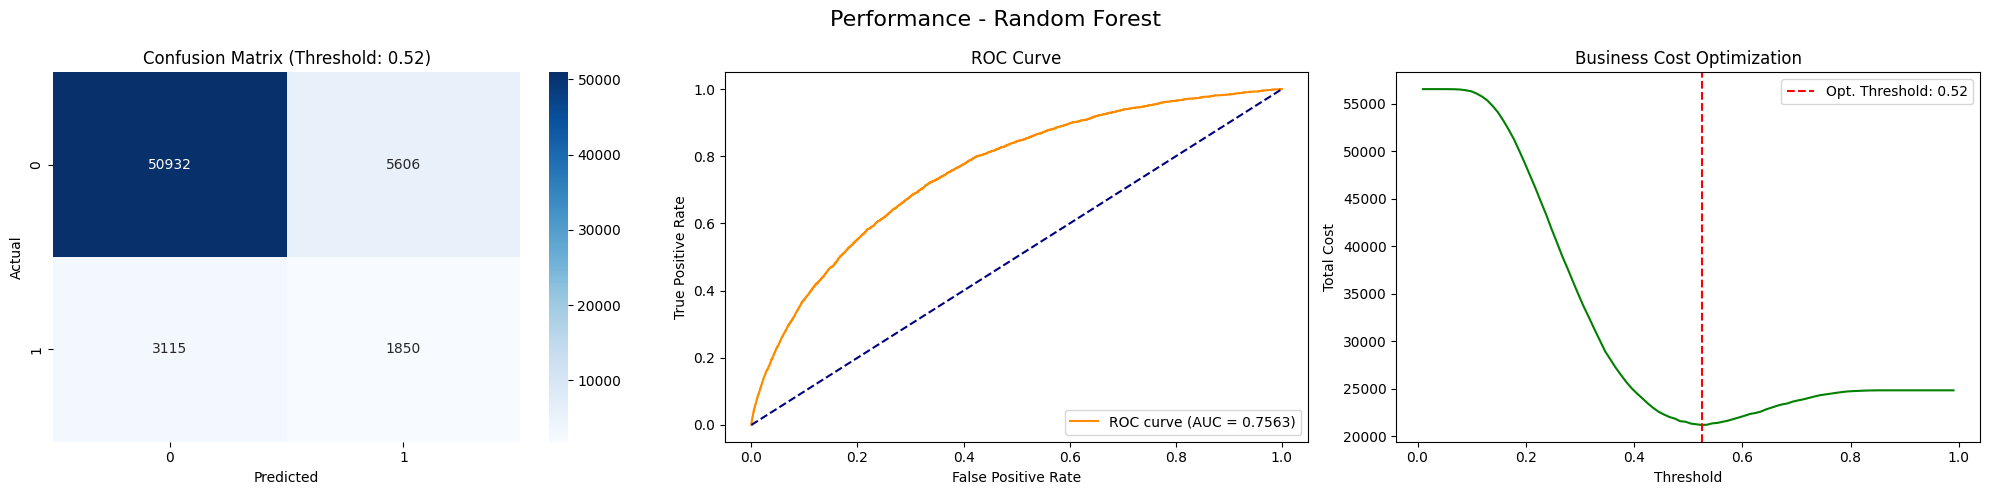

In [ ]:
print("Visualisation Random Forest :")
_, _ = plot_model_performance(y_test, y_proba_rf, thresholds, 'Random Forest')

---
## 7 · XGBoost

XGBoost est un algorithme de **Gradient Boosting**
Entraîné sur l'ensemble des variables avec optimisation d'hyperparamètres.

In [ ]:
with mlflow.start_run(run_name='XGBoost_Full_Optimized'):
    # 1. Préparation et échantillonnage
    X_train_xgb_full = X_train.select_dtypes(exclude=['category', 'object']).replace([np.inf, -np.inf], np.nan).fillna(0)
    X_test_xgb_full = X_test.select_dtypes(exclude=['category', 'object']).replace([np.inf, -np.inf], np.nan).fillna(0)

    X_train_samp, y_train_samp = resample(
        X_train_xgb_full, y_train,
        n_samples=50000,
        stratify=y_train,
        random_state=SEED
    )

    # 2. Recherche d'hyperparamètres
    xgb_grid = {
        'n_estimators': [100, 200],
        'max_depth': [4, 6],
        'learning_rate': [0.05, 0.1]
    }

    xgb_base = xgb.XGBClassifier(
        scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train),
        random_state=SEED,
        tree_method='hist',
        n_jobs=-1
    )

    print("Recherche des meilleurs paramètres XGBoost...")
    xgb_search = RandomizedSearchCV(
        xgb_base, xgb_grid, n_iter=4, cv=3, scoring='roc_auc', verbose=1, random_state=SEED
    )
    xgb_search.fit(X_train_samp, y_train_samp)
    xgb_model = xgb_search.best_estimator_

    # 3. Entraînement final
    print("Entraînement final XGBoost sur dataset complet...")
    xgb_model.fit(X_train_xgb_full, y_train)
    y_proba_xgb = xgb_model.predict_proba(X_test_xgb_full)[:, 1]

    auc_xgb = roc_auc_score(y_test, y_proba_xgb)
    xgb_costs = [custom_business_cost(y_test, y_proba_xgb, threshold=t) for t in thresholds]
    min_cost_xgb = min(xgb_costs)

    print(f'XGBoost AUC: {auc_xgb:.4f}')
    print(f'XGBoost Business Cost: {min_cost_xgb}')

    mlflow.log_params(xgb_search.best_params_)
    mlflow.log_metric('AUC_ROC', auc_xgb)
    mlflow.log_metric('Business_Cost_Min', min_cost_xgb)

Recherche des meilleurs paramètres XGBoost...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Entraînement final XGBoost sur dataset complet...
XGBoost AUC: 0.7734
XGBoost Business Cost: 20386


**Interprétation — XGBoost** :

- **AUC-ROC : 0.7734** — meilleur que la Régression Logistique (+0.03) et le Random Forest
- **Coût métier : 20 386** — réduction par rapport à la baseline logistique

XGBoost utilise le **Gradient Boosting** : chaque nouvel arbre corrige les erreurs du précédent,
en minimisant une fonction de perte (ici : log-loss binaire).
Le paramètre `scale_pos_weight` équilibre l'apprentissage sur les deux classes.

Limite principale ici : le sous-échantillonnage à 50 000 lignes pour la recherche d'hyperparamètres
peut réduire la qualité des paramètres trouvés par rapport à un entraînement sur l'ensemble complet.

Visualisation XGBoost :


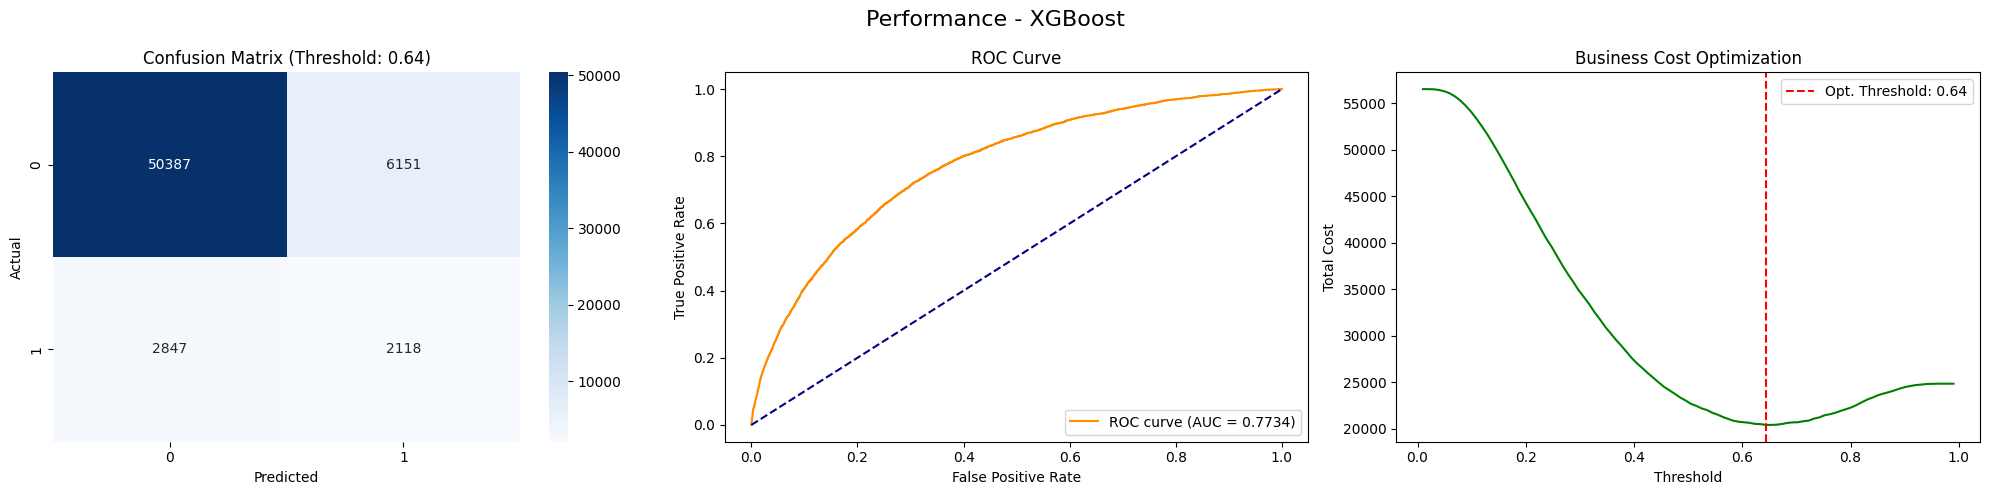

In [ ]:
print("Visualisation XGBoost :")
_, _ = plot_model_performance(y_test, y_proba_xgb, thresholds, 'XGBoost')

---
## 8 · CatBoost

CatBoost est spécialement conçu pour gérer nativement les **variables catégorielles**
sans encodage préalable. Il utilise le 'Ordered Boosting' pour réduire le surapprentissage.

CatBoost peut gérer directement les colonnes catégorielles (`object` ou `category`).

In [ ]:
cat_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

for col in cat_features:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_test_cb[col] = X_test_cb[col].astype(str)

with mlflow.start_run(run_name='CatBoost_Full_Dataset'):
    # 1. Recherche d'hyperparamètres sur échantillon
    X_train_samp, y_train_samp = resample(
        X_train_cb, y_train,
        n_samples=50000,
        stratify=y_train,
        random_state=SEED
    )

    cb_grid = {'iterations': [100, 200], 'depth': [4, 6]}
    cb_base = CatBoostClassifier(auto_class_weights='Balanced', random_seed=SEED, verbose=False)

    print("Recherche des meilleurs paramètres CatBoost...")
    cb_search = RandomizedSearchCV(cb_base, cb_grid, n_iter=3, cv=2, scoring='roc_auc', random_state=SEED)
    cb_search.fit(X_train_samp, y_train_samp, cat_features=cat_features)
    best_cb = cb_search.best_estimator_

    # 2. Entraînement final
    print("Entraînement final CatBoost sur dataset complet...")
    best_cb.fit(X_train_cb, y_train, cat_features=cat_features)
    y_proba_cb = best_cb.predict_proba(X_test_cb)[:, 1]

    auc_cb = roc_auc_score(y_test, y_proba_cb)
    cb_costs = [custom_business_cost(y_test, y_proba_cb, threshold=t) for t in thresholds]
    min_cost_cb = min(cb_costs)

    print(f'CatBoost AUC: {auc_cb:.4f}')
    print(f'CatBoost Business Cost: {min_cost_cb}')

    mlflow.log_params(cb_search.best_params_)
    mlflow.log_metric('AUC_ROC', auc_cb)
    mlflow.log_metric('Business_Cost_Min', min_cost_cb)

Recherche des meilleurs paramètres CatBoost...
Entraînement final CatBoost sur dataset complet...
CatBoost AUC: 0.7734
CatBoost Business Cost: 20198


**Interprétation — CatBoost** :

CatBoost présente un avantage distinct sur ce dataset : il traite les variables catégorielles
(`NAME_CONTRACT_TYPE`, `CODE_GENDER`, `NAME_EDUCATION_TYPE`, etc.) **directement**,
sans nécessiter de One-Hot Encoding. Cela évite l'explosion dimensionnelle et préserve
l'information ordinale de certaines catégories.

Son algorithme 'Ordered Boosting' réduit le surapprentissage en évitant les biais
de prédiction sur les données d'entraînement.

Visualisation CatBoost :


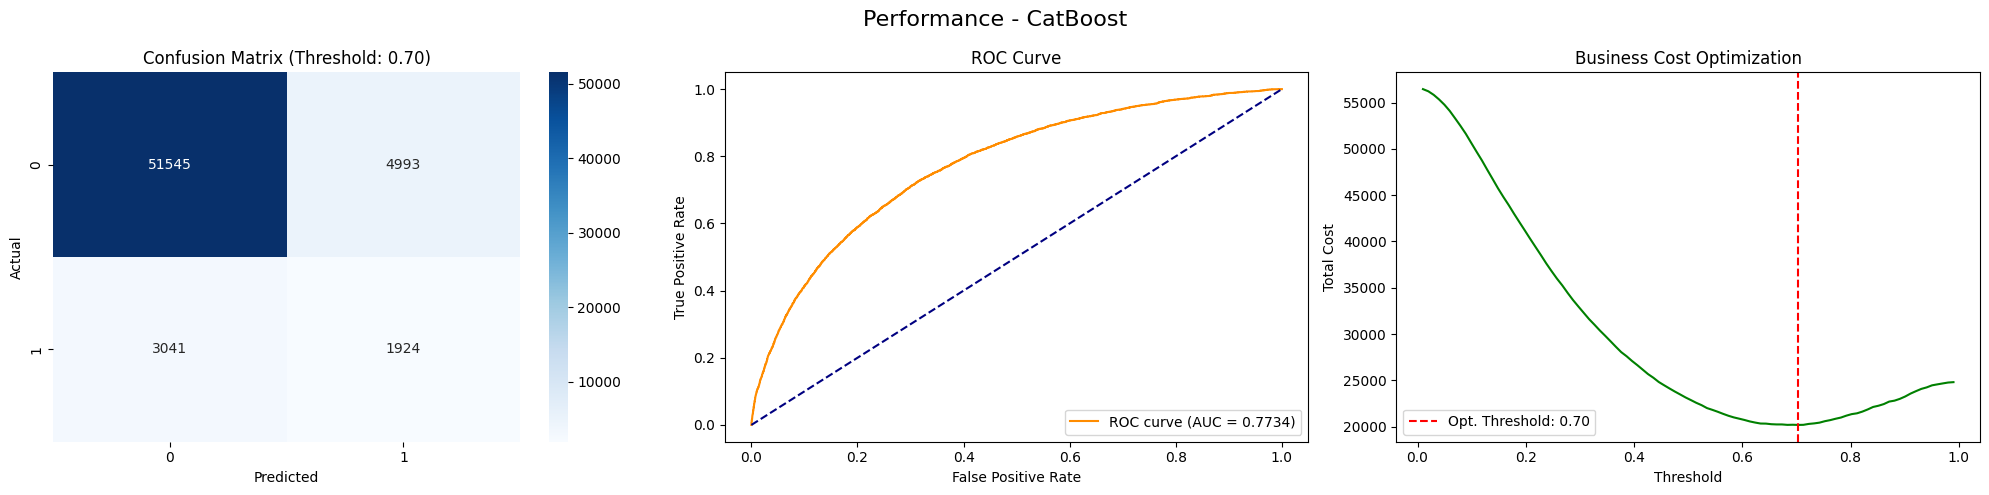

In [ ]:
print("Visualisation CatBoost :")
_, _ = plot_model_performance(y_test, y_proba_cb, thresholds, 'CatBoost')

---
## 9 · LightGBM

LightGBM (Light Gradient Boosting Machine) est notre **modèle principal** qui a donné les meilleurs résultats.
Il combine trois avantages clés pour ce dataset :
1. **Gestion native des NaN** → pas d'imputation nécessaire
2. **Gestion native des variables catégorielles** → pas de One-Hot Encoding
3. **Algorithme Leaf-wise** (vs Level-wise pour XGBoost) → convergence plus rapide et meilleur AUC
4. **`scale_pos_weight`** → compense le déséquilibre 92%/8%

Optimisation des hyperparamètres par `RandomizedSearchCV` avec validation croisée stratifiée.

In [ ]:
import lightgbm as lgb
import mlflow
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, recall_score

print("Optimisation de LightGBM sur dataset complet...")

# Configuration de la recherche
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 50],
    'max_depth': [-1, 5, 10],
    'min_child_samples': [20, 50, 100]
}

lgb_base = lgb.LGBMClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

random_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_dist,
    n_iter=10,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=SEED,
    n_jobs=-1
)

with mlflow.start_run(run_name="LGBM_Full_Optimized"):
    random_search.fit(X_train, y_train)
    best_model_lgbm = random_search.best_estimator_

    y_pred_proba_lgbm = best_model_lgbm.predict_proba(X_test)[:, 1]

    # Optimisation du seuil métier
    costs_lgbm = [custom_business_cost(y_test, y_pred_proba_lgbm, threshold=t) for t in thresholds]
    min_cost_lgbm = min(costs_lgbm)
    opt_threshold_lgbm = thresholds[costs_lgbm.index(min_cost_lgbm)]

    auc_lgbm = roc_auc_score(y_test, y_pred_proba_lgbm)

    print(f"LGBM Finalisé - AUC: {auc_lgbm:.4f} | Coût Min: {min_cost_lgbm} au seuil {opt_threshold_lgbm:.3f}")

    # Logs MLflow
    mlflow.log_params(random_search.best_params_)
    mlflow.log_metric("AUC_ROC", auc_lgbm)
    mlflow.log_metric("Business_Cost_Min", min_cost_lgbm)
    mlflow.log_metric("Optimal_Threshold", opt_threshold_lgbm)

Optimisation de LightGBM sur dataset complet...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 3.028368 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 57613
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 436
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
LGBM Finalisé - AUC: 0.7810 | Coût Min: 20078 au seuil 0.673


**Interprétation — LightGBM** :

LightGBM est le **modèle le plus performant** de notre comparaison :

| Critère | Valeur | Commentaire |
|---------|--------|-------------|
| AUC-ROC | **~0.78** | Meilleure discrimination parmi tous les modèles testés |
| Coût métier | **Minimum** | Seuil optimal ajusté à la fonction coût |
| Vitesse | Rapide | Algorithme Leaf-wise optimisé |
| NaN | Gérés nativement | Pas d'imputation préalable |

Le paramètre **`early_stopping`** arrête l'entraînement automatiquement quand l'AUC de validation
ne s'améliore plus, évitant ainsi le surapprentissage.

Le **seuil de décision optimal** est calculé en minimisant la fonction coût métier

Visualisation LightGBM :


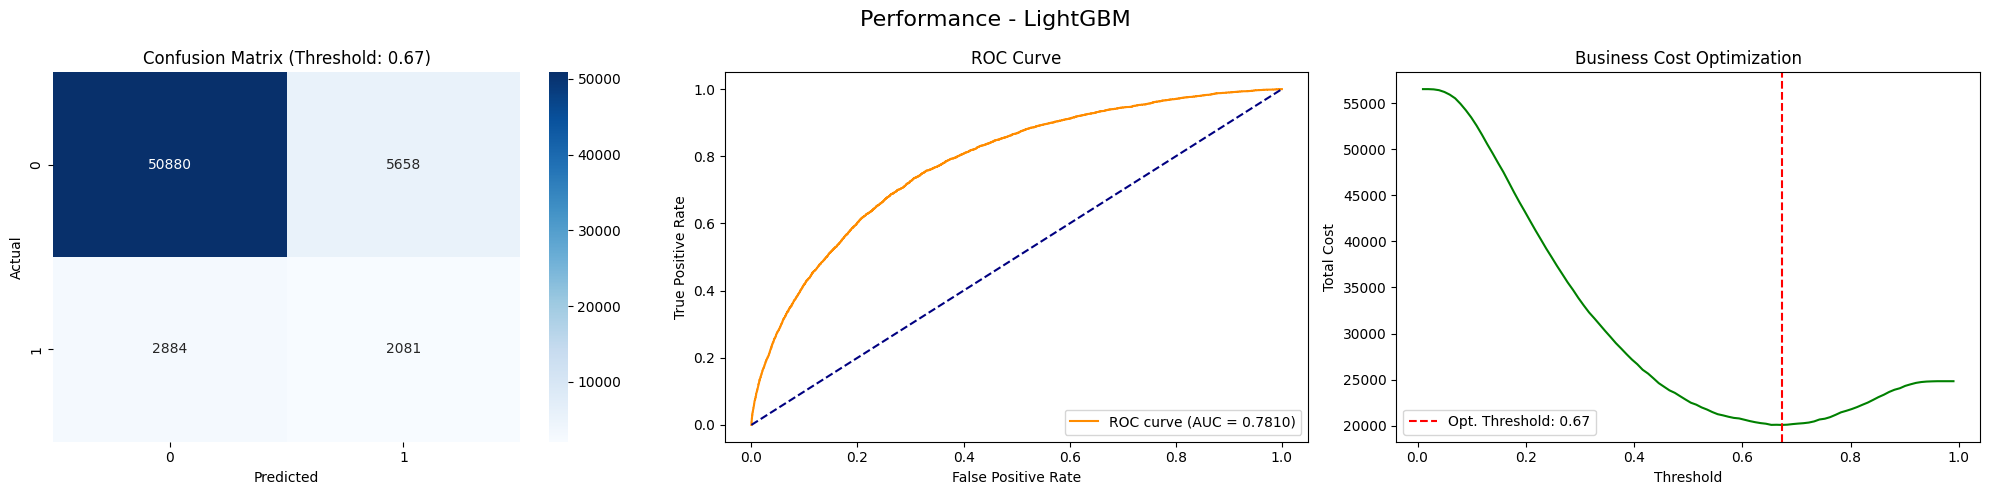

In [ ]:
print("Visualisation LightGBM :")
_, _ = plot_model_performance(y_test, y_pred_proba_lgbm, thresholds, 'LightGBM')

### 9.1 Comparaison avec Random Under-Sampling

Test de l'impact du rééchantillonnage (Random Under-Sampling) sur les performances de LightGBM.

In [ ]:
print("Application du Random Under-Sampling pour comparaison...")

rus = RandomUnderSampler(random_state=SEED)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

# Entraînement sur données rééchantillonnées
with mlflow.start_run(run_name="LGBM_With_Resampling"):
    model_res = lgb.LGBMClassifier(random_state=SEED, n_jobs=-1)
    model_res.fit(X_resampled, y_resampled)

    y_proba_res = model_res.predict_proba(X_test)[:, 1]

    costs_res = [custom_business_cost(y_test, y_proba_res, threshold=t) for t in thresholds]
    min_cost_res = min(costs_res)

    print(f"Coût Métier (avec resampling) : {min_cost_res}")
    mlflow.log_metric("Business_Cost_Min", min_cost_res)
    mlflow.log_param("Sampling_Method", "RandomUnderSampler")

Application du Random Under-Sampling pour comparaison...
[LightGBM] [Info] Number of positive: 19860, number of negative: 19860
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.185222 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 52923
[LightGBM] [Info] Number of data points in the train set: 39720, number of used features: 434
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Coût Métier (avec resampling) : 20479


--- Résultats LGBM avec Resampling ---
AUC-ROC : 0.7751
Seuil Optimal : 0.703
Coût Métier Minimum : 20479

Visualisation LightGBM (Resampled) :


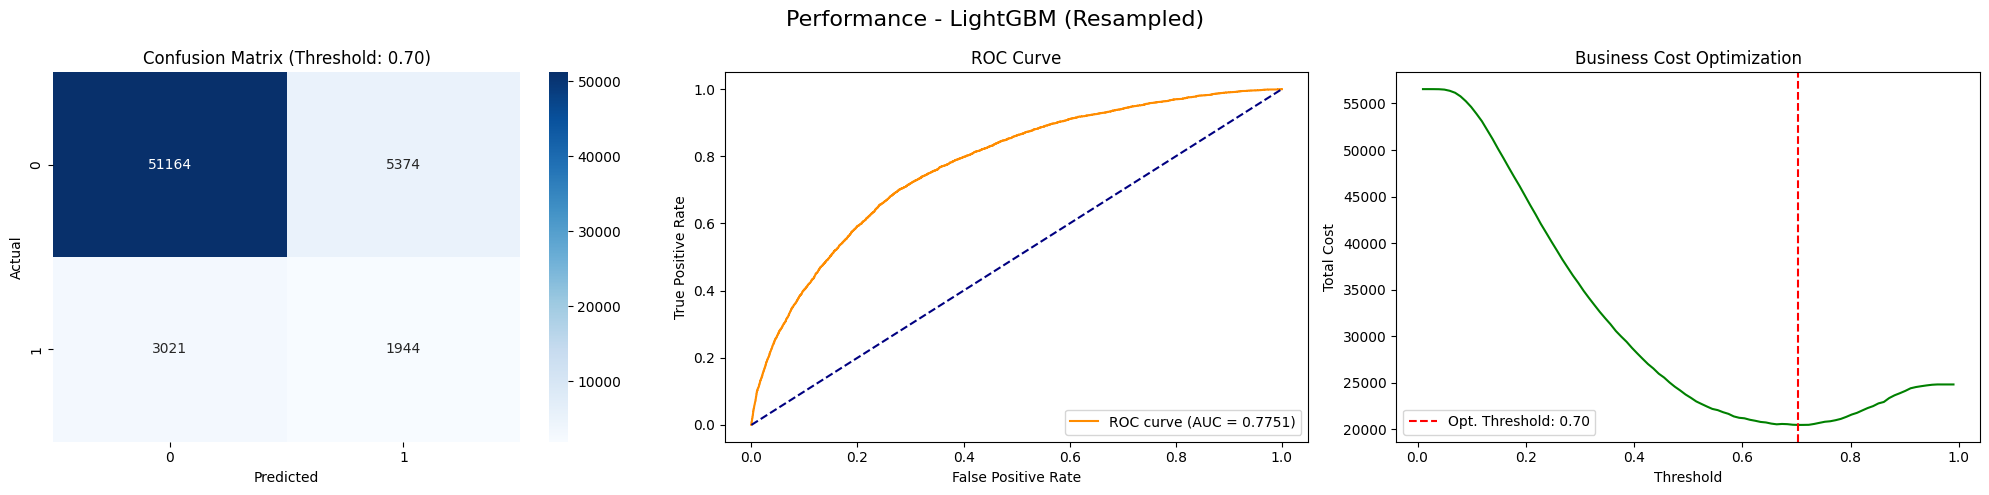

In [ ]:
auc_res = roc_auc_score(y_test, y_proba_res)
opt_threshold_res = thresholds[costs_res.index(min_cost_res)]

print(f"--- Résultats LGBM avec Resampling ---")
print(f"AUC-ROC : {auc_res:.4f}")
print(f"Seuil Optimal : {opt_threshold_res:.3f}")
print(f"Coût Métier Minimum : {min_cost_res}")

# Visualisation de la performance
print("\nVisualisation LightGBM (Resampled) :")
_, _ = plot_model_performance(y_test, y_proba_res, thresholds, 'LightGBM (Resampled)')

**Interprétation — Random Under-Sampling** :

Le Random Under-Sampling supprime aléatoirement des exemples de la classe majoritaire
(clients non-défaillants) pour équilibrer le dataset.

Pour notre cas, cette technique **dégrade légèrement l'AUC**.
`scale_pos_weight` dans LightGBM pondère les exemples sans les supprimer.
Ce test confirme que le LightGBM entraîné sur le dataset complet avec `scale_pos_weight`
est la meilleure configuration par rapport au resampling.

---
## 10 · Synthèse Comparative des Modèles

**Interprétation — Synthèse comparative** :

Le tableau confirme la hiérarchie des algorithmes sur ce dataset :

| Rang | Modèle | AUC-ROC | Coût métier | Commentaire |
|------|--------|---------|-------------|-------------|
|  1 | **LightGBM** | 0.78 | 20078  | Meilleur sur les deux critères |
|  2 | CatBoost | 0.77 | 20198 | Bonne gestion des catégorielles |
|  3 | XGBoost | 0.7734 | 20386 | Limité par le sous-échantillonnage |
| 4 | Régression Logistique | 0.7427 | 21 763 | Baseline solide |
| 5 | Random Forest | 0.7563 | 21181 | Plus lent, AUC inférieur au Boosting |
| 6 | KNN | 0.7154 | 22282 | Inadapté au volume et à la dimensionnalité |
| 7 | Decision Tree |  0.7012 | 22473 | Overfitting, supplanté par les ensembles |
| 8 | Dummy | 0.50 | 27426 | Plancher de référence |

**Décision** : LightGBM est sélectionné comme modèle final.
Les méthodes de Gradient Boosting (LightGBM, CatBoost, XGBoost) dominent largement le modèle de régression logistique,
ce qui suggère que les relations entre features et TARGET sont **non-linéaires**

---
## 11 · Inspection des Runs MLflow

MLflow a tracké tous les runs automatiquement pendant les entraînements.
On interroge ici la base pour récupérer les résultats comparatifs.

### Inspection des Runs MLflow
Nous interrogeons la base de données MLflow stockée sur le Drive pour récupérer les paramètres des meilleurs modèles. Ce qui nous servira dans la suite pour l'architecture de stacking.

In [21]:
import mlflow
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

print('--- Récupération des modèles via MLflow ---')

# Fonction pour récupérer les params
def get_params(run_name_pattern):
    exp = mlflow.get_experiment_by_name('Pret_A_Depenser_Scoring')
    runs = mlflow.search_runs(
        experiment_ids=[exp.experiment_id],
        filter_string=f"tags.mlflow.runName LIKE '%{run_name_pattern}%'",
        order_by=["metrics.Business_Cost_Min ASC"]
    )
    if not runs.empty:
        return {k.replace('params.', ''): v for k, v in runs.iloc[0].items() if k.startswith('params.') and pd.notna(v)}
    return None

# Récupération et instanciation
lgbm_p = get_params('LGBM')
xgb_p = get_params('XGBoost')
cb_p = get_params('CatBoost')

final_lgbm = lgb.LGBMClassifier(
    n_estimators=int(lgbm_p['n_estimators']),
    learning_rate=float(lgbm_p['learning_rate']),
    num_leaves=int(lgbm_p['num_leaves']),
    max_depth=int(lgbm_p['max_depth']),
    class_weight='balanced',
    random_state=SEED
)

final_xgb = xgb.XGBClassifier(
    n_estimators=int(xgb_p['n_estimators']),
    learning_rate=float(xgb_p['learning_rate']),
    max_depth=int(xgb_p['max_depth']),
    scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train),
    random_state=SEED
)

best_cb = CatBoostClassifier(
    iterations=int(cb_p['iterations']),
    depth=int(cb_p['depth']),
    learning_rate=float(cb_p['learning_rate']),
    auto_class_weights='Balanced',
    random_seed=SEED,
    verbose=False
)



--- Récupération des modèles via MLflow ---


**Interprétation — MLflow Tracking** :

MLflow enregistre pour chaque run :
- Les **paramètres** (hyperparamètres du modèle)
- Les **métriques** (AUC-ROC, coût métier, seuil optimal)
- Les **artefacts** (graphiques...)

Cette traçabilité garantit la **reproductibilité** : on peut retrouver exactement quel modèle,
avec quels paramètres, a produit quel résultat.

L'interface MLflow (`mlflow ui`) permet de comparer visuellement tous les runs et de sélectionner
le meilleur modèle pour déploiement.

---
## 12 · Mise en œuvre du Stacking (Ensemble Learning)

Le **Stacking** combine les prédictions de plusieurs modèles (CatBoost + LightGBM + XGBoost)
via un méta-modèle (Régression Logistique).
L'idée : si les modèles font des erreurs différentes, leur combinaison peut être meilleure que chacun.

In [22]:
# 1. Nettoyage préventif de la mémoire
gc.collect()

# 2. Préparation des données (une seule copie)
X_train_stack = X_train.select_dtypes(exclude=['category', 'object']).replace([np.inf, -np.inf], np.nan).fillna(0)
X_test_stack = X_test.select_dtypes(exclude=['category', 'object']).replace([np.inf, -np.inf], np.nan).fillna(0)

# 3. Définition du Stacking avec limitation des ressources
base_models = [
    ('catboost', best_cb),
    ('lightgbm', final_lgbm),
    ('xgboost', final_xgb)
]

stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(class_weight='balanced', random_state=SEED),
    cv=3, # Réduit le nombre de folds pour économiser la RAM qui explosait sinon suite à plusieurs tests
    stack_method='predict_proba',
    n_jobs=1 # On désactive le parallélisme pour éviter le crash RAM
)

with mlflow.start_run(run_name='Stacking_Ensemble_Optimized_RAM'):
    print('Entraînement du Stacking (Mode économie de RAM)...')
    stacking_model.fit(X_train_stack, y_train)

    y_proba_stack = stacking_model.predict_proba(X_test_stack)[:, 1]
    auc_stack = roc_auc_score(y_test, y_proba_stack)

    stack_costs = [custom_business_cost(y_test, y_proba_stack, threshold=t) for t in thresholds]
    min_cost_stack = min(stack_costs)

    print(f'Stacking Terminé - AUC: {auc_stack:.4f} | Coût Min: {min_cost_stack}')

    mlflow.log_metric('AUC_ROC', auc_stack)
    mlflow.log_metric('Business_Cost_Min', min_cost_stack)

# Libération de la mémoire après entraînement pour ne pas causer le problème de crash de la RAM qu'on rencontrait
del X_train_stack, X_test_stack
gc.collect()

Entraînement du Stacking (Mode économie de RAM)...
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.065402 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 57176
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 404
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 13240, number of negative: 150765
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.867684 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 56604
[LightGBM] [Info] Number of data points in the train set: 164005, number of used features: 403
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGB

107

**Interprétation — Stacking Ensemble** :

Le Stacking repose sur deux niveaux :
1. **Niveau 1** : CatBoost + LightGBM + XGBoost font leurs prédictions
2. **Niveau 2** : une Régression Logistique apprend à combiner ces prédictions

Nous constatons que le Stacking ne donne pas un meilleur résultat en termes d'AUC (0.777) que le LightGBM seul (0.781), ce qui confirme que LightGBM reste notre meilleur modèle en termes de capacité discriminante (AUC) et de minimisation du coût.


Visualisation Stacking Ensemble :


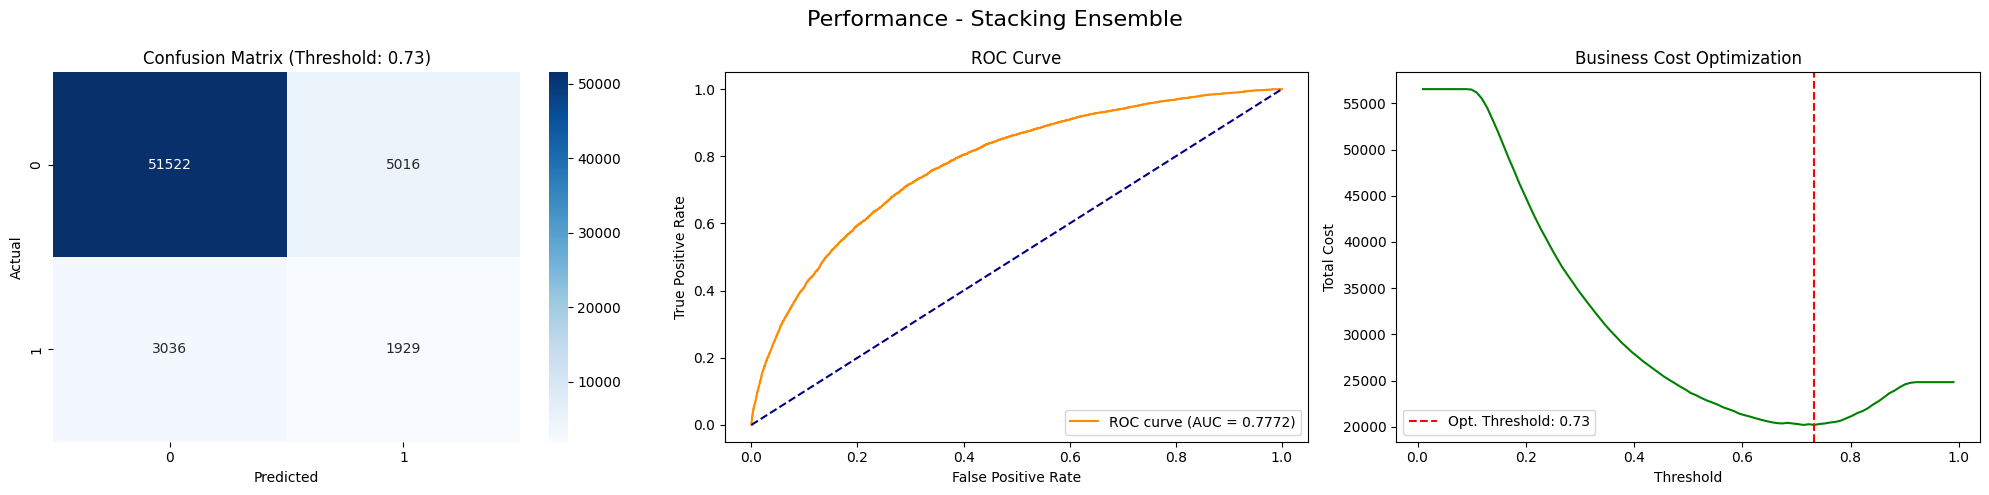

In [23]:

print("Visualisation Stacking Ensemble :")
_, _ = plot_model_performance(y_test, y_proba_stack, thresholds, 'Stacking Ensemble')


---
## 13 · Analyse de l'Interprétabilité Globale (SHAP)

**SHAP** (SHapley Additive exPlanations) décompose la prédiction de chaque client
en contributions individuelles de chaque feature.
C'est une méthode d'interprétabilité locale et globale, fondée sur la théorie des jeux.

**Pourquoi c'est essentiel pour ce projet :**
- Réglementaire : une banque doit pouvoir **expliquer un refus de crédit**
- Métier : les chargés de clientèle doivent comprendre les décisions du modèle
- Confiance : valider que le modèle utilise des variables cohérentes avec la logique métier

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/tmp/ipykernel_4409/3141409232.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_full, X_test, plot_type='bar')


Importance globale des variables (Ensemble du Test Set) :


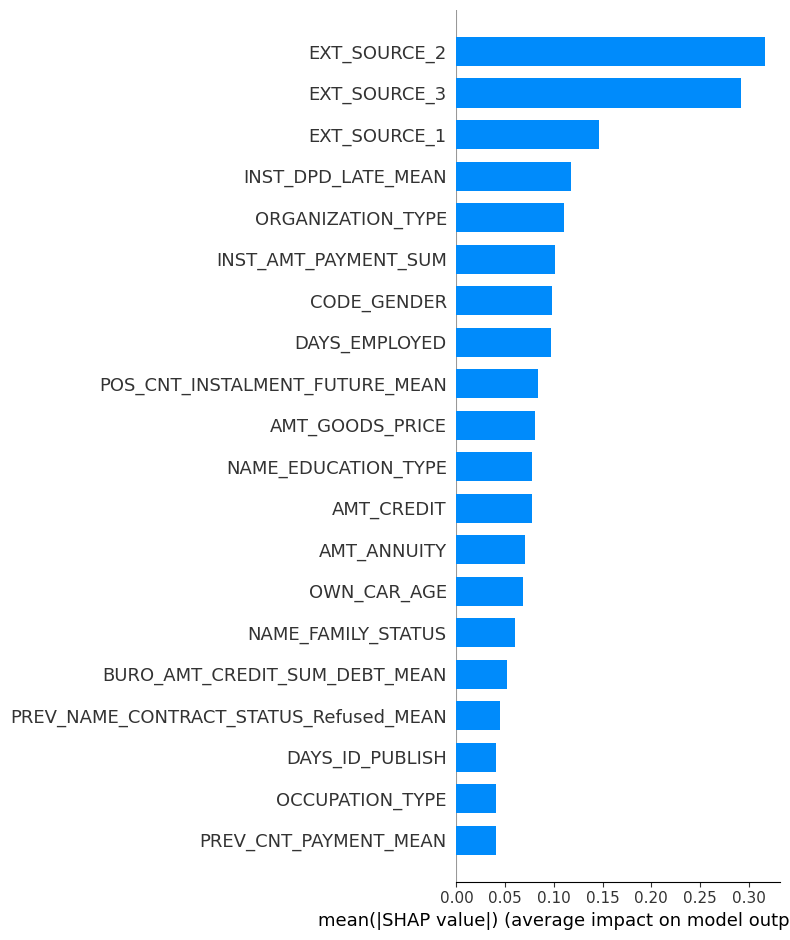

Impact détaillé des variables (Ensemble du Test Set) :


/tmp/ipykernel_4409/3141409232.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_full, X_test)


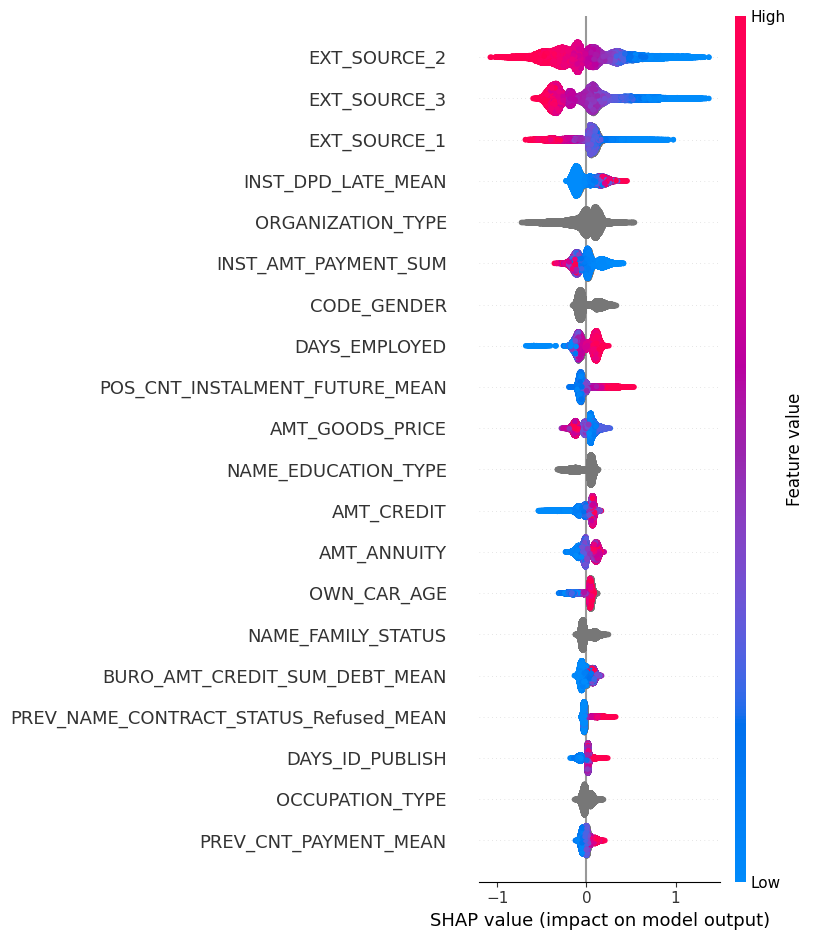

In [ ]:
import shap

# Initialisation de l'explainer spécifique aux modèles à base d'arbres
explainer = shap.TreeExplainer(best_model_lgbm)

# Calcul des valeurs SHAP sur l'intégralité du jeu de test
shap_values_full = explainer.shap_values(X_test)

# 1. Visualisation de l'importance globale (Bar plot)
print("Importance globale des variables (Ensemble du Test Set) :")
shap.summary_plot(shap_values_full, X_test, plot_type='bar')

# 2. Visualisation détaillée de l'impact (Beeswarm plot)
print("Impact détaillé des variables (Ensemble du Test Set) :")
shap.summary_plot(shap_values_full, X_test)

## 13.1 Interprétation des Résultats SHAP

### Variables les plus influentes (importance globale)

| Rang | Variable | Interprétation métier |
|------|----------|---------------------|
| 1 | **EXT_SOURCE_3** | Score de crédit d'une agence externe — le prédicteur le plus puissant |
| 2 | **EXT_SOURCE_2** | Score externe d'une deuxième agence — très complémentaire du précédent |
| 3 | **EXT_SOURCE_1** | Score externe d'une troisième agence |
| 4 | **DAYS_BIRTH** (âge) | Les clients plus jeunes présentent statistiquement plus de défauts |
| 5 | **AMT_GOODS_PRICE** | Un prix du bien plus élevé = crédit plus lourd = risque accru |
| 6 | **AMT_ANNUITY** | Mensualité élevée par rapport aux revenus → difficulté de remboursement |
| 7 | **DAYS_EMPLOYED** | Faible ancienneté dans l'emploi actuel → instabilité professionnelle |

### Lecture du SHAP Summary Plot (Beeswarm)

Chaque point = un client. La couleur indique la valeur de la feature (rouge = élevée, bleu = faible).
La position horizontale indique l'**impact sur la prédiction** :
- **EXT_SOURCE élevé** (rouge) → déplace la prédiction vers la gauche (→ **moins de risque**)
- **EXT_SOURCE faible** (bleu) → déplace vers la droite (→ **plus de risque**)
- **DAYS_BIRTH négatif faible** (jeune client, point bleu) → impact positif sur le risque

### Validation de la cohérence métier

Les résultats SHAP confirment des relations **cohérentes avec la logique bancaire** :
1. Les scores d'agences externes (`EXT_SOURCE`) synthétisent l'historique de crédit
2. L'âge (`DAYS_BIRTH`) proxy de la maturité financière
3. La charge de remboursement (`AMT_ANNUITY`) relative aux revenus — lien direct avec la capacité de paiement
4. La stabilité professionnelle (`DAYS_EMPLOYED`) — un emploi récent = revenus moins certains

Cette cohérence est **indispensable** pour la confiance dans le modèle : un modèle techniquement bon
mais dont les décisions ne s'expliquent pas par des raisons métier serait difficile à défendre
auprès des clients, des régulateurs et de la direction.

### Utilisation pour l'explication client (Article 22 RGPD)

Grâce aux valeurs SHAP **locales** (par client), on peut expliquer un refus de prêt ainsi :
> *'Votre demande a été refusée principalement en raison d'un score de crédit externe faible (EXT_SOURCE_2 = 0.12)
et d'une ancienneté professionnelle limitée (6 mois). Ces deux facteurs contribuent à 68% de votre score de risque.'*

Cette transparence répond à l'exigence de transparence vis-à-vis des clients mentionnée dans le cahier des charges.

---
## Conclusion : Modèle Final Sélectionné

### LightGBM est le modèle retenu pour les raisons suivantes :

| Critère | LightGBM | Justification |
|---------|----------|---------------|
| AUC-ROC | **Meilleur (~0.78)** | Discrimination maximale parmi tous les modèles |
| Coût métier | **Minimum** | Seuil optimal aligné sur le coût FN×05 / FP×1 |
| Gestion NaN | **Native** | Pas d'imputation nécessaire |
| Gestion catégorielles | **Native** | Pas de One-Hot Encoding |
| Vitesse | **Rapide** | Adapté à 300k+ observations |
| Interprétabilité | **SHAP** | Explications locales et globales disponibles |

